**CUSTOMER PROFITABILITY AND LIFETIME VALUE ANALYSIS**

In [ ]:
import pandas as pd

df = pd.read_csv("data.csv", encoding='cp1252')
df = df.dropna(subset=['CustomerID'])
df = df[df['Quantity'] > 0]
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [ ]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


Revenue = Quantity × UnitPrice

Since cost isn't given assume
Cost = 60% of revenue

In [ ]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]
df["Cost"] = df["Revenue"] * 0.6
df["Profit"] = df["Revenue"] - df["Cost"]

Grouping by Customer ID

In [ ]:
customer_data = df.groupby("CustomerID").agg({
    "Revenue":"sum",
    "Profit":"sum",
    "InvoiceNo":"nunique"
}).reset_index()

customer_data.rename(columns={"InvoiceNo":"TotalOrders"}, inplace=True)

Compute Average Order value

In [ ]:
customer_data["AvgOrderValue"] = customer_data["Revenue"] / customer_data["TotalOrders"]

Select features for clustering

In [ ]:
features = customer_data[["Revenue","Profit","TotalOrders","AvgOrderValue"]]

standardize the data

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

Find optimal number of clusters

In [ ]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

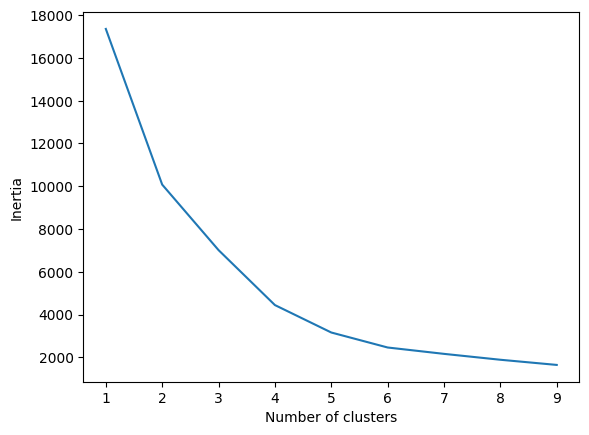

In [ ]:
import matplotlib.pyplot as plt

plt.plot(range(1,10), inertia)
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
customer_data["Segment"] = kmeans.fit_predict(scaled_features)

In [ ]:
segment_summary = customer_data.groupby("Segment").mean()
print(segment_summary)

           CustomerID        Revenue        Profit  TotalOrders  AvgOrderValue
Segment                                                                       
0        15301.502564    1402.108173    560.843269     3.778788     364.311054
1        16277.250000  219559.792500  87823.917000    95.250000    3264.775517
2        14396.000000  122828.050000  49131.220000     1.500000   80709.925000
3        15094.860465   41220.199302  16488.079721    45.139535    1880.804734


Interpretation:

Segment 0 → Premium customers
Segment 1 → Regular buyers
Segment 2 → Low value customers
Segment 3 → Frequent but low profit customers

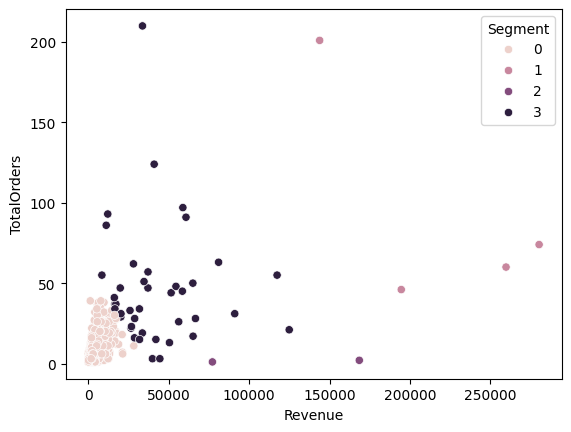

In [ ]:
import seaborn as sns

sns.scatterplot(
    data=customer_data,
    x="Revenue",
    y="TotalOrders",
    hue="Segment"
)
plt.show()

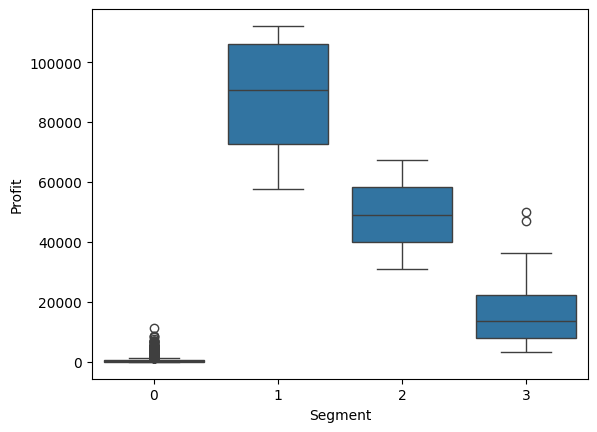

In [ ]:
sns.boxplot(
    data=customer_data,
    x="Segment",
    y="Profit"
)
plt.show()

In [ ]:
customer_sorted = customer_data.sort_values(by="Profit", ascending=False)

In [ ]:
customer_sorted["CumulativeProfit"] = customer_sorted["Profit"].cumsum()

total_profit = customer_sorted["Profit"].sum()

customer_sorted["ProfitShare"] = (
    customer_sorted["CumulativeProfit"] / total_profit
)

In [ ]:
import numpy as np
customer_sorted["CustomerPercent"] = (
    np.arange(1, len(customer_sorted) + 1) / len(customer_sorted)
)

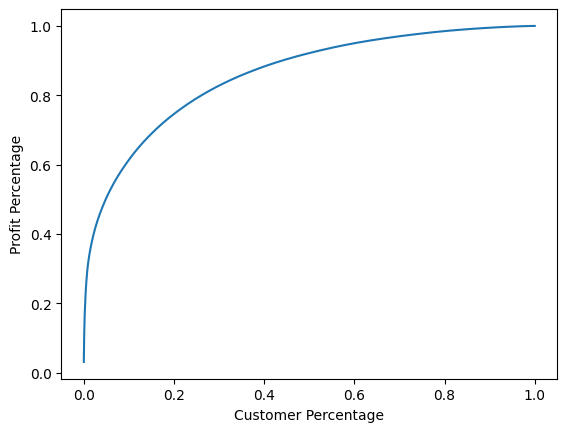

In [ ]:
plt.plot(customer_sorted["CustomerPercent"],
         customer_sorted["ProfitShare"])
plt.xlabel("Customer Percentage")
plt.ylabel("Profit Percentage")
plt.show()

Interpretation:

20% of customers → 70% profit

50% of customers → 90% profit